In [1]:
# Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from traffic.core import Traffic

import os
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split


---
# Normaly Flights

In [2]:
df = pd.read_csv('new_df.csv')
df

,time,icao24,lat,lon,velocity,heading,vertrate,callsign,onground,alert,spi,squawk,baroaltitude,geoaltitude,lastposupdate,lastcontact,hour
0,1478875626,a1fb8f,33.755679,-84.465466,227.710488,348.664682,0.00000,9211,False,False,False,706.0,11582.40,12031.98,1.478876e+09,1.478876e+09,1.478873e+09
1,1478875627,a1fb8f,33.757645,-84.465917,227.710488,348.664682,0.00000,9211,False,False,False,706.0,11582.40,12031.98,1.478876e+09,1.478876e+09,1.478873e+09
2,1478875628,a1fb8f,33.758743,-84.466198,227.710488,348.664682,0.00000,9211,False,False,False,706.0,11582.40,12031.98,1.478876e+09,1.478876e+09,1.478873e+09
3,1478875629,a1fb8f,33.761536,-84.466870,227.710488,348.664682,0.00000,9211,False,False,False,706.0,11590.02,12031.98,1.478876e+09,1.478876e+09,1.478873e+09
4,1478875630,a1fb8f,33.763733,-84.467411,227.710488,348.664682,0.00000,9211,False,False,False,706.0,11582.40,12031.98,1.478876e+09,1.478876e+09,1.478873e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8952848,1585086698,a6b009,33.830887,-84.475390,92.772669,245.424573,9.75360,N53WA,False,False,False,7171.0,4846.32,4991.10,1.585087e+09,1.585087e+09,1.585084e+09
8952849,1585086699,a6b009,33.830535,-84.476280,92.772669,245.424573,9.75360,N53WA,False,False,False,7171.0,4861.56,5006.34,1.585087e+09,1.585087e+09,1.585084e+09
8952850,1585086700,a6b009,33.830210,-84.477081,92.772669,245.424573,9.42848,N53WA,False,False,False,7171.0,4869.18,5013.96,1.585087e+09,1.585087e+09,1.585084e+09
8952851,1585086701,a6b009,33.829791,-84.478168,92.521291,245.002353,9.42848,N53WA,False,False,False,7171.0,4884.42,5029.20,1.585087e+09,1.585087e+09,1.585084e+09


In [3]:
df = df.drop(['onground','alert','spi','squawk','lastposupdate','lastcontact','hour'], axis=1)

In [4]:
head100 = df.head(100)
head100

,time,icao24,lat,lon,velocity,heading,vertrate,callsign,baroaltitude,geoaltitude
0,1478875626,a1fb8f,33.755679,-84.465466,227.710488,348.664682,0.0,9211,11582.40,12031.98
1,1478875627,a1fb8f,33.757645,-84.465917,227.710488,348.664682,0.0,9211,11582.40,12031.98
2,1478875628,a1fb8f,33.758743,-84.466198,227.710488,348.664682,0.0,9211,11582.40,12031.98
3,1478875629,a1fb8f,33.761536,-84.466870,227.710488,348.664682,0.0,9211,11590.02,12031.98
4,1478875630,a1fb8f,33.763733,-84.467411,227.710488,348.664682,0.0,9211,11582.40,12031.98
...,...,...,...,...,...,...,...,...,...,...
95,1478879567,a12ce9,33.757278,-84.465469,232.153365,348.366366,0.0,N175MX,13106.40,13517.88
96,1478879568,a12ce9,33.759293,-84.465974,232.153365,348.366366,0.0,N175MX,13106.40,13517.88
97,1478879569,a12ce9,33.761359,-84.466496,232.153365,348.366366,0.0,N175MX,13106.40,13525.50
98,1478879570,a12ce9,33.761359,-84.466496,232.153365,348.366366,0.0,N175MX,13106.40,13525.50


In [5]:
def extract_flight_info(df):
    data = df.copy()
    data['time_diff'] = data['time'].diff()
    data['flight'] = (data['time_diff'] > 30).cumsum()
    flight_time_based = {name: group for name, group in data.groupby('flight')}

    # Create flight_time_info dataframe
    flight_time_info = pd.DataFrame({
        'ICAO24': [group['icao24'].iloc[0] for group in flight_time_based.values()],
        'Callsign': [group['callsign'].iloc[0] for group in flight_time_based.values()],
        'Start Time': [group['time'].min() for group in flight_time_based.values()],
        'End Time': [group['time'].max() for group in flight_time_based.values()],
        'Duration(s)': [(group['time'].max() - group['time'].min()) for group in flight_time_based.values()]
    })
    flight_time_info = flight_time_info.sort_values(by='Duration(s)', ascending=False)
    flight_time_info = flight_time_info.reset_index(drop=True)
    return flight_time_info

flight_time_info = extract_flight_info(df)
flight_time_info

,ICAO24,Callsign,Start Time,End Time,Duration(s)
0,c050b5,ROU1660,1573104000,1581787940,8683940
1,a20d77,AAY1732,1573051672,1581726811,8675139
2,abba43,DAL503,1573052170,1581726832,8674662
3,a90af1,DAL1502,1573920315,1582309613,8389298
4,ab5a01,SCX314,1573921000,1582309848,8388848
...,...,...,...,...,...
156034,a73a47,JBU581,1552086159,1552086159,0
156035,ab7a21,DAL2204,1524758291,1524758291,0
156036,a8ec57,UAL2091,1583353718,1583353718,0
156037,a2c93f,EDV5294,1524715197,1524715197,0


In [6]:
flight_time_info = flight_time_info[flight_time_info['Duration(s)'] < 1000000]

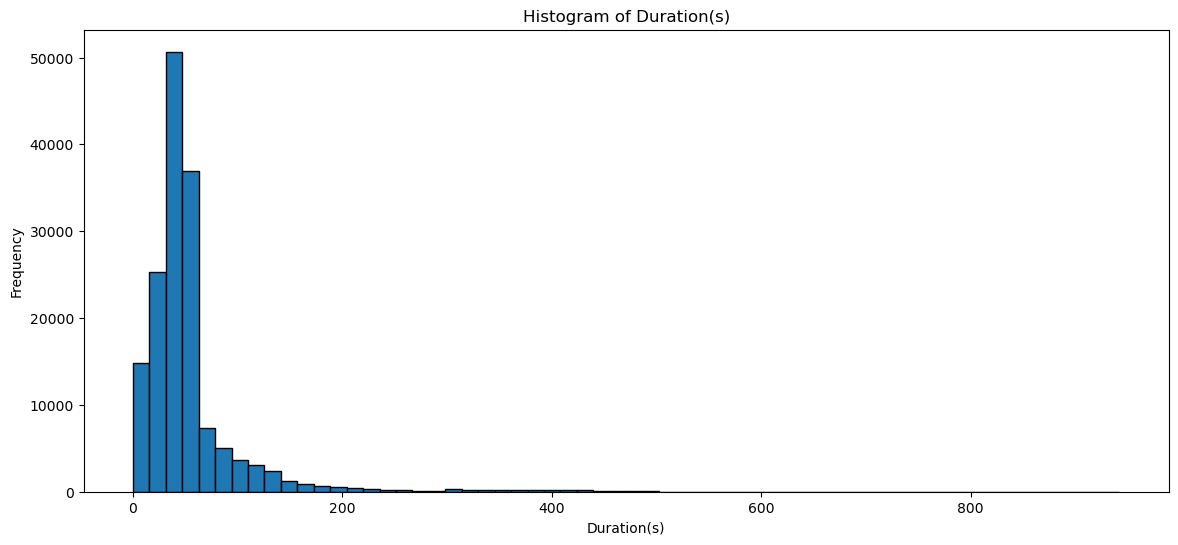

In [7]:
plt.figure(figsize=(14, 6))
plt.hist(flight_time_info['Duration(s)'], bins=60, edgecolor='black')
plt.title('Histogram of Duration(s)')
plt.xlabel('Duration(s)')
plt.ylabel('Frequency')
plt.show()

In [8]:
pair_count = df.groupby(['callsign', 'icao24']).size().reset_index(name='count')
pair_count = pair_count.sort_values(by='count', ascending=False)
pair_count.head(10)

,callsign,icao24,count
81471,N34K,a3bbd6,4512
79968,N1103G,a02efb,3287
84407,N845UP,ab943c,3185
83815,N748RE,aa11be,3106
80925,N25NR,a25661,2994
83656,N717NC,a9973d,2945
83677,N7210C,a9a99e,2892
79940,N107CL,a01ef2,2815
84891,N929WG,ace194,2782
84252,N81771,ab26c4,2746


In [9]:
import requests
from bs4 import BeautifulSoup

def info_flight(callsigns):
    results = {}
    
    # Create a session to persist certain parameters across requests
    session = requests.Session()

    # Set the base URL and headers to mimic a browser request
    base_url = "https://www.flightaware.com/resources/registration/"
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.36',
        'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,*/*;q=0.8',
        'Accept-Language': 'en-US,en;q=0.5',
        'Referer': 'https://www.google.com',
        'Connection': 'keep-alive',
        'Upgrade-Insecure-Requests': '1'
    }

    for callsign in callsigns:
        url = base_url + callsign
        
        try:
            # Make the HTTP request with headers
            response = session.get(url, headers=headers)

            # Check the HTTP response status
            if response.status_code == 200:
                # Parse the HTML content
                soup = BeautifulSoup(response.text, 'html.parser')

                # Find the specific section containing the aircraft type
                aircraft_summary = soup.find("div", {"class": "medium-3 columns"})

                # Extract the aircraft type if available
                if aircraft_summary:
                    aircraft_type = aircraft_summary.get_text(strip=True)
                    results[callsign] = aircraft_type
                else:
                    results[callsign] = "Aircraft type not found"
            else:
                results[callsign] = f"Error: HTTP status code {response.status_code}"

        except Exception as e:
            results[callsign] = f"Error: {str(e)}"
    
    return results

In [10]:
callsigns = ['N34K', 'N1103G', 'N845UP', 'N748RE','N25NR']
aircraft_types = info_flight(callsigns)
for callsign, aircraft_type in aircraft_types.items():
    print(f"Aircraft type for callsign {callsign}: {aircraft_type}")

Aircraft type for callsign N34K: 1981 CESSNA A185FFixed wing single engine(6 seats / 1 engine)
Aircraft type for callsign N1103G: 1997 RAYTHEON AIRCRAFT COMPANY C90AFixed wing multi engine(9 seats / 2 engines)
Aircraft type for callsign N845UP: 2014 DASSAULT FALCON 2000EXFixed wing multi engine(19 seats / 2 engines)
Aircraft type for callsign N748RE: 2013 DASSAULT AVIATION FALCON 2000EXFixed wing multi engine(19 seats / 2 engines)
Aircraft type for callsign N25NR: 2019 BELL HELICOPTER TEXTRON CANADA 407Rotorcraft(8 seats / 1 engine)


---
## **Predict Tranjaction For E34K**

In [11]:
def extract_flight_id(df):
    data = df.copy()
    data['time_diff'] = data['time'].diff()
    data['flight'] = (data['time_diff'] > 30).cumsum()
    return data

flight_E34K = df[(df['callsign'] == 'N34K') & (df['icao24'] == 'a3bbd6')]
flight_E34K = extract_flight_id(flight_E34K)
flight_E34K = flight_E34K.drop(['time_diff', 'icao24', 'callsign'], axis=1)
flight_E34K = flight_E34K.reset_index(drop=True)
flight_E34K


,time,lat,lon,velocity,heading,vertrate,baroaltitude,geoaltitude,flight
0,1488311090,33.848145,-84.457005,60.739260,181.941486,-0.65024,1463.04,1485.90,0
1,1488311091,33.847806,-84.456997,60.739260,181.941486,-0.65024,1463.04,1485.90,0
2,1488311092,33.847806,-84.456997,60.739260,181.941486,-0.32512,1463.04,1485.90,0
3,1488311093,33.846503,-84.457054,61.227482,180.962864,-0.32512,1463.04,1485.90,0
4,1488311094,33.845947,-84.457061,61.227482,180.962864,-0.32512,1463.04,1485.90,0
...,...,...,...,...,...,...,...,...,...
4507,1583856394,33.752979,-84.401550,60.409396,175.114797,0.00000,1432.56,1478.28,28
4508,1583856395,33.751556,-84.401345,60.409396,175.114797,0.00000,1432.56,1478.28,28
4509,1583856396,33.751024,-84.401321,59.896837,175.072890,0.32512,1432.56,1478.28,28
4510,1583856397,33.751024,-84.401321,59.896837,175.072890,0.32512,1432.56,1478.28,28


In [12]:
from sklearn.preprocessing import MinMaxScaler

train_data = flight_E34K[flight_E34K['flight'] < 28].copy()  
test_data = flight_E34K[flight_E34K['flight'] == 28].copy()  

columns_to_scale = ['lat', 'lon', 'velocity', 'heading', 'vertrate', 'baroaltitude', 'geoaltitude']
scaler = MinMaxScaler()

train_data[columns_to_scale] = scaler.fit_transform(train_data[columns_to_scale])
test_data[columns_to_scale] = scaler.transform(test_data[columns_to_scale])

print('Train data after normalization:')
train_data.head()

Train data after normalization:


,time,lat,lon,velocity,heading,vertrate,baroaltitude,geoaltitude,flight
0,1488311090,0.983333,0.231085,0.421018,0.480770,0.425,0.723404,0.744565,0
1,1488311091,0.979944,0.231167,0.421018,0.480770,0.425,0.723404,0.744565,0
2,1488311092,0.979944,0.231167,0.421018,0.480770,0.450,0.723404,0.744565,0
3,1488311093,0.966884,0.230592,0.431550,0.473432,0.450,0.723404,0.744565,0
4,1488311094,0.961318,0.230522,0.431550,0.473432,0.450,0.723404,0.744565,0


In [13]:
print('Test data after normalization:')
test_data.head()

Test data after normalization:


,time,lat,lon,velocity,heading,vertrate,baroaltitude,geoaltitude,flight
4325,1583856212,0.999845,0.606248,0.416781,0.374247,0.475,0.702128,0.73913,28
4326,1583856213,0.994403,0.607821,0.416781,0.374247,0.475,0.702128,0.73913,28
4327,1583856214,0.989296,0.609065,0.416781,0.374247,0.475,0.702128,0.73913,28
4328,1583856215,0.984709,0.610191,0.416781,0.374247,0.500,0.702128,0.73913,28
4329,1583856216,0.978288,0.611881,0.427628,0.375016,0.475,0.702128,0.73913,28


In [14]:
def prepare_data(data, n_steps):
    X, y = [], []
    for i in range(len(data) - n_steps):
        X.append(data.iloc[i:i+n_steps][['lat', 'lon', 'velocity', 'heading', 'vertrate','baroaltitude','geoaltitude']].values)
        y.append(data.iloc[i+n_steps][['lat', 'lon', 'geoaltitude']].values)
    return np.array(X), np.array(y)

n_steps = 10

X_train, y_train = prepare_data(train_data, n_steps)
X_test, y_test = prepare_data(test_data, n_steps)

X_train = X_train.reshape((X_train.shape[0], n_steps, X_train.shape[2]))
X_test = X_test.reshape((X_test.shape[0], n_steps, X_test.shape[2]))

print('Shape of X_train_lstm:', X_train.shape)
print('Shape of y_train_lstm:', y_train.shape)
print('Shape of X_test_lstm:', X_test.shape)
print('Shape of y_test_lstm:', y_test.shape)

Shape of X_train_lstm: (4315, 10, 7)
Shape of y_train_lstm: (4315, 3)
Shape of X_test_lstm: (177, 10, 7)
Shape of y_test_lstm: (177, 3)


---
### **LSTM Model**

In [15]:
from keras.models import Sequential
from keras.layers import LSTM, Dense

In [16]:
model_lstm = Sequential()
model_lstm.add(LSTM(50, activation='relu', input_shape=(n_steps, X_train.shape[2])))
model_lstm.add(Dense(3)) # 3 output features: latitude, longitude, and geoaltitude
model_lstm.compile(optimizer='adam', loss='mse')

model_lstm.fit(X_train, y_train, epochs=50, verbose=1)

mse_lstm = model_lstm.evaluate(X_test, y_test, verbose=0)
print(f'Mean Squared Error on Test Set (lat, lon, geoaltitude) using LSTM: {mse_lstm}')

Metal device set to: Apple M1 Pro

systemMemory: 16.00 GB
maxCacheSize: 5.33 GB



2024-07-08 11:47:25.930214: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2024-07-08 11:47:25.930611: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/50


2024-07-08 11:47:26.166710: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz
2024-07-08 11:47:26.515204: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


135/135 [==============================] - 13s 93ms/step - loss: 0.0306
Epoch 2/50
135/135 [==============================] - 12s 91ms/step - loss: 0.0052
Epoch 3/50
135/135 [==============================] - 12s 92ms/step - loss: 0.0041
Epoch 4/50
135/135 [==============================] - 12s 92ms/step - loss: 0.0033
Epoch 5/50
135/135 [==============================] - 13s 98ms/step - loss: 0.0028
Epoch 6/50
135/135 [==============================] - 13s 94ms/step - loss: 0.0027
Epoch 7/50
135/135 [==============================] - 13s 97ms/step - loss: 0.0025
Epoch 8/50
135/135 [==============================] - 13s 97ms/step - loss: 0.0025
Epoch 9/50
135/135 [==============================] - 13s 97ms/step - loss: 0.0022
Epoch 10/50
135/135 [==============================] - 13s 97ms/step - loss: 0.0021
Epoch 11/50
135/135 [==============================] - 13s 97ms/step - loss: 0.0021
Epoch 12/50
135/135 [==============================] - 13s 97ms/step - loss: 0.0022
Epoch 13/50


2024-07-08 11:58:19.081526: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


Mean Squared Error on Test Set (lat, lon, geoaltitude) using LSTM: 0.0001276065595448017


In [17]:
y_pred_lstm = model_lstm.predict(X_test)
y_pred_lat_lstm = y_pred_lstm[:, 0]
y_pred_lon_lstm = y_pred_lstm[:, 1]
y_pred_geoaltitude_lstm = y_pred_lstm[:, 2]

6/6 [==============================] - 0s 19ms/step


2024-07-08 11:58:19.444794: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


---
### **GRU Model**

In [18]:
from keras.layers import GRU

In [19]:
# Create and train GRU model
model_gru = Sequential()
model_gru.add(GRU(50, activation='relu', input_shape=(n_steps, X_train.shape[2])))
model_gru.add(Dense(3))  # Output layer for latitude, longitude, geoaltitude
model_gru.compile(optimizer='adam', loss='mse')

model_gru.fit(X_train, y_train, epochs=50, verbose=1)

# Evaluate GRU model
mse_gru = model_gru.evaluate(X_test, y_test, verbose=0)
print(f'Mean Squared Error on Test Set (lat, lon, geoaltitude) using GRU: {mse_gru}')

Epoch 1/50


2024-07-08 11:58:20.079591: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


135/135 [==============================] - 16s 112ms/step - loss: 0.0471
Epoch 2/50
135/135 [==============================] - 15s 110ms/step - loss: 0.0036
Epoch 3/50
135/135 [==============================] - 15s 111ms/step - loss: 0.0028
Epoch 4/50
135/135 [==============================] - 15s 111ms/step - loss: 0.0025
Epoch 5/50
135/135 [==============================] - 15s 110ms/step - loss: 0.0023
Epoch 6/50
135/135 [==============================] - 15s 109ms/step - loss: 0.0022
Epoch 7/50
135/135 [==============================] - 15s 109ms/step - loss: 0.0021
Epoch 8/50
135/135 [==============================] - 15s 109ms/step - loss: 0.0020
Epoch 9/50
135/135 [==============================] - 15s 109ms/step - loss: 0.0020
Epoch 10/50
135/135 [==============================] - 15s 108ms/step - loss: 0.0020
Epoch 11/50
135/135 [==============================] - 15s 109ms/step - loss: 0.0019
Epoch 12/50
135/135 [==============================] - 15s 108ms/step - loss: 0.0019


2024-07-08 12:11:02.624519: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


Mean Squared Error on Test Set (lat, lon, geoaltitude) using GRU: 0.0008120291749946773


In [20]:
# Predict with GRU model
y_pred_gru = model_gru.predict(X_test)
y_pred_lat_gru = y_pred_gru[:, 0]
y_pred_lon_gru = y_pred_gru[:, 1]
y_pred_geoaltitude_gru = y_pred_gru[:, 2]

4/6 [===================>..........] - ETA: 0s

2024-07-08 12:11:03.054750: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


6/6 [==============================] - 0s 28ms/step


---
### SimpleRNN Model

In [21]:
from keras.layers import SimpleRNN, Dense

In [22]:
# Define and train SimpleRNN model
model_rnn = Sequential()
model_rnn.add(SimpleRNN(50, activation='relu', input_shape=(n_steps, X_train.shape[2])))
model_rnn.add(Dense(3))
model_rnn.compile(optimizer='adam', loss='mse')
model_rnn.fit(X_train, y_train, epochs=50, verbose=1)

# Predict using SimpleRNN model
y_pred_rnn = model_rnn.predict(X_test)
y_pred_lat_rnn = y_pred_rnn[:, 0]
y_pred_lon_rnn = y_pred_rnn[:, 1]
y_pred_geoaltitude_rnn = y_pred_rnn[:, 2]

Epoch 1/50


2024-07-08 12:11:03.680000: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


135/135 [==============================] - 6s 40ms/step - loss: 0.0388
Epoch 2/50
135/135 [==============================] - 6s 41ms/step - loss: 0.0042
Epoch 3/50
135/135 [==============================] - 5s 40ms/step - loss: 0.0034
Epoch 4/50
135/135 [==============================] - 5s 40ms/step - loss: 0.0030
Epoch 5/50
135/135 [==============================] - 5s 40ms/step - loss: 0.0027
Epoch 6/50
135/135 [==============================] - 5s 40ms/step - loss: 0.0025
Epoch 7/50
135/135 [==============================] - 5s 40ms/step - loss: 0.0024
Epoch 8/50
135/135 [==============================] - 5s 40ms/step - loss: 0.0023
Epoch 9/50
135/135 [==============================] - 5s 40ms/step - loss: 0.0022
Epoch 10/50
135/135 [==============================] - 5s 40ms/step - loss: 0.0022
Epoch 11/50
135/135 [==============================] - 5s 40ms/step - loss: 0.0021
Epoch 12/50
135/135 [==============================] - 5s 40ms/step - loss: 0.0020
Epoch 13/50
135/135 [===

2024-07-08 12:15:33.627276: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


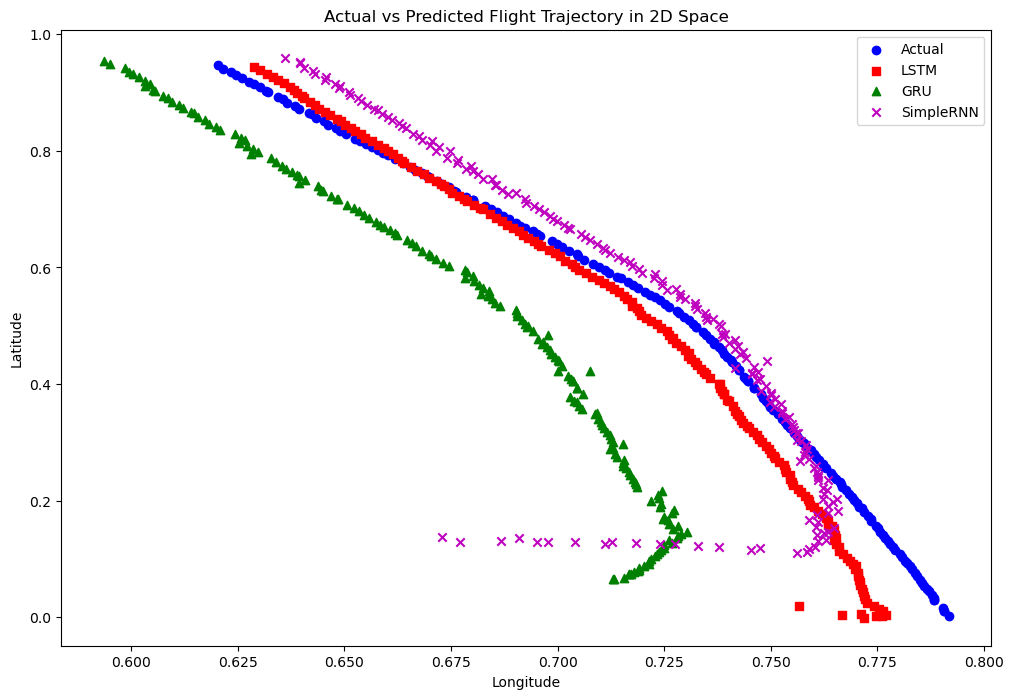

In [23]:
plt.figure(figsize=(12, 8))
plt.scatter(test_data['lon'].values[n_steps:], test_data['lat'].values[n_steps:], c='b', marker='o', label='Actual')
plt.scatter(y_pred_lon_lstm, y_pred_lat_lstm, c='r', marker='s', label='LSTM')
plt.scatter(y_pred_lon_gru, y_pred_lat_gru, c='g', marker='^', label='GRU')
plt.scatter(y_pred_lon_rnn, y_pred_lat_rnn, c='m', marker='x', label='SimpleRNN')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.title('Actual vs Predicted Flight Trajectory in 2D Space')
plt.show()


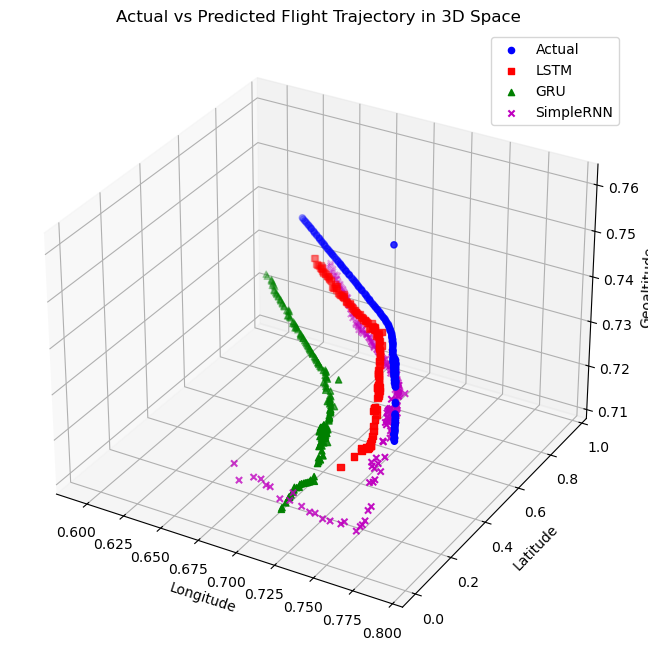

In [24]:
fig = plt.figure(figsize=(16, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(test_data['lon'].values[n_steps:], test_data['lat'].values[n_steps:], test_data['geoaltitude'].values[n_steps:], c='b', marker='o', label='Actual')
ax.scatter(y_pred_lon_lstm, y_pred_lat_lstm, y_pred_geoaltitude_lstm, c='r', marker='s', label='LSTM')
ax.scatter(y_pred_lon_gru, y_pred_lat_gru, y_pred_geoaltitude_gru, c='g', marker='^', label='GRU')
ax.scatter(y_pred_lon_rnn, y_pred_lat_rnn, y_pred_geoaltitude_rnn, c='m', marker='x', label='SimpleRNN')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_zlabel('Geoaltitude')

plt.legend()
plt.title('Actual vs Predicted Flight Trajectory in 3D Space')
plt.show()


In [25]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Calculate errors for LSTM
error_lat_lstm = y_test[:, 0] - y_pred_lat_lstm
error_lon_lstm = y_test[:, 1] - y_pred_lon_lstm
error_geoaltitude_lstm = y_test[:, 2] - y_pred_geoaltitude_lstm
euclidean_distance_lstm = np.sqrt(error_lat_lstm**2 + error_lon_lstm**2 + error_geoaltitude_lstm**2)

error_df_lstm = pd.DataFrame({
    'Error Latitude': error_lat_lstm,
    'Error Longitude': error_lon_lstm,
    'Error Altitude': error_geoaltitude_lstm,
    'Euclidean Distance': euclidean_distance_lstm
})

# Calculate errors for GRU
error_lat_gru = y_test[:, 0] - y_pred_lat_gru
error_lon_gru = y_test[:, 1] - y_pred_lon_gru
error_geoaltitude_gru = y_test[:, 2] - y_pred_geoaltitude_gru
euclidean_distance_gru = np.sqrt(error_lat_gru**2 + error_lon_gru**2 + error_geoaltitude_gru**2)

error_df_gru = pd.DataFrame({
    'Error Latitude': error_lat_gru,
    'Error Longitude': error_lon_gru,
    'Error Altitude': error_geoaltitude_gru,
    'Euclidean Distance': euclidean_distance_gru
})

# Calculate errors for RNN
error_lat_rnn = y_test[:, 0] - y_pred_lat_rnn
error_lon_rnn = y_test[:, 1] - y_pred_lon_rnn
error_geoaltitude_rnn = y_test[:, 2] - y_pred_geoaltitude_rnn
euclidean_distance_rnn = np.sqrt(error_lat_rnn**2 + error_lon_rnn**2 + error_geoaltitude_rnn**2)

error_df_rnn = pd.DataFrame({
    'Error Latitude': error_lat_rnn,
    'Error Longitude': error_lon_rnn,
    'Error Altitude': error_geoaltitude_rnn,
    'Euclidean Distance': euclidean_distance_rnn
})

In [26]:
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Error Latitude', 'Error Longitude', 'Error Altitude', 'Euclidean Distance')
)

# Add traces for GRU errors
fig.add_trace(go.Scatter(y=error_df_gru['Error Latitude'], mode='lines', name='GRU Error Latitude'), row=1, col=1)
fig.add_trace(go.Scatter(y=error_df_gru['Error Longitude'], mode='lines', name='GRU Error Longitude'), row=1, col=2)
fig.add_trace(go.Scatter(y=error_df_gru['Error Altitude'], mode='lines', name='GRU Error Altitude'), row=2, col=1)
fig.add_trace(go.Scatter(y=error_df_gru['Euclidean Distance'], mode='lines', name='GRU Euclidean Distance'), row=2, col=2)

# Add traces for LSTM errors
fig.add_trace(go.Scatter(y=error_df_lstm['Error Latitude'], mode='lines', name='LSTM Error Latitude'), row=1, col=1)
fig.add_trace(go.Scatter(y=error_df_lstm['Error Longitude'], mode='lines', name='LSTM Error Longitude'), row=1, col=2)
fig.add_trace(go.Scatter(y=error_df_lstm['Error Altitude'], mode='lines', name='LSTM Error Altitude'), row=2, col=1)
fig.add_trace(go.Scatter(y=error_df_lstm['Euclidean Distance'], mode='lines', name='LSTM Euclidean Distance'), row=2, col=2)

# Add traces for RNN errors
fig.add_trace(go.Scatter(y=error_df_rnn['Error Latitude'], mode='lines', name='RNN Error Latitude'), row=1, col=1)
fig.add_trace(go.Scatter(y=error_df_rnn['Error Longitude'], mode='lines', name='RNN Error Longitude'), row=1, col=2)
fig.add_trace(go.Scatter(y=error_df_rnn['Error Altitude'], mode='lines', name='RNN Error Altitude'), row=2, col=1)
fig.add_trace(go.Scatter(y=error_df_rnn['Euclidean Distance'], mode='lines', name='RNN Euclidean Distance'), row=2, col=2)

fig.update_layout(
    height=800, 
    width=1600, 
    title_text="Error Analysis (LSTM vs GRU vs RNN)",
    annotations=[
        dict(
            x=0.225, y=1.05,
            xref='paper', yref='paper',
            text='Error Latitude',
            showarrow=False,
            font=dict(size=14)
        ),
        dict(
            x=0.775, y=1.05,
            xref='paper', yref='paper',
            text='Error Longitude',
            showarrow=False,
            font=dict(size=14)
        ),
        dict(
            x=0.225, y=0.475,
            xref='paper', yref='paper',
            text='Error Altitude',
            showarrow=False,
            font=dict(size=14)
        ),
        dict(
            x=0.775, y=0.475,
            xref='paper', yref='paper',
            text='Euclidean Distance',
            showarrow=False,
            font=dict(size=14)
        )
    ]
)
fig.show()

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Define a function to calculate Mean Absolute Error (MAE), Mean Relative Error (MRE), and Root Mean Squared Error (RMSE)
def calculate_errors(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred, multioutput='raw_values')
    mre = np.mean(np.abs((y_true - y_pred) / y_true), axis=0)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred, multioutput='raw_values'))
    return mae, mre, rmse

def create_error_table(y_test, y_pred_lstm, y_pred_gru, y_pred_rnn):
    mae_lstm, mre_lstm, rmse_lstm = calculate_errors(y_test, y_pred_lstm)
    mae_gru, mre_gru, rmse_gru = calculate_errors(y_test, y_pred_gru)
    mae_rnn, mre_rnn, rmse_rnn = calculate_errors(y_test, y_pred_rnn)
    
    error_table = pd.DataFrame({
        'Model': ['LSTM', 'GRU', 'RNN'],
        'MAE Latitude ': [mae_lstm[0], mae_gru[0], mae_rnn[0]],
        'MAE Longitude ': [mae_lstm[1], mae_gru[1], mae_rnn[1]],
        'MAE Altitude ': [mae_lstm[2], mae_gru[2], mae_rnn[2]],
        'MRE Latitude ': [mre_lstm[0], mre_gru[0], mre_rnn[0]],
        'MRE Longitude ': [mre_lstm[1], mre_gru[1], mre_rnn[1]],
        'MRE Altitude ': [mre_lstm[2], mre_gru[2], mre_rnn[2]],
        'RMSE Latitude ': [rmse_lstm[0], rmse_gru[0], rmse_rnn[0]],
        'RMSE Longitude ': [rmse_lstm[1], rmse_gru[1], rmse_rnn[1]],
        'RMSE Altitude ': [rmse_lstm[2], rmse_gru[2], rmse_rnn[2]]
    })
    return error_table

error_table = create_error_table(y_test, y_pred_lstm, y_pred_gru, y_pred_rnn)
error_table

,Model,MAE Latitude,MAE Longitude,MAE Altitude,MRE Latitude,MRE Longitude,MRE Altitude,RMSE Latitude,RMSE Longitude,RMSE Altitude
0,LSTM,0.015233,0.006614,0.004407,0.154593,0.008969,0.005951,0.017132,0.007892,0.005199
1,GRU,0.010140,0.041643,0.018487,0.352762,0.056926,0.024978,0.014963,0.043175,0.018657
2,RNN,0.023119,0.013634,0.013823,0.745958,0.018417,0.018676,0.031683,0.025685,0.014774
